In [1]:
# BLOCK 0 — imports
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import least_squares

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


In [2]:
# BLOCK 1 — load the npz and inspect its structure
model_name = "4i2ygs9p"
layer_name = "stages.0.0.dwconv"
npz_path = (
    f"/home/tomasdu/repos/trained_models/gradmaps/{model_name}/{layer_name}"
    f"/gradmaps_{model_name}_{layer_name}.npz"
)

d       = np.load(npz_path)
patches = d["patches"]   # (C, feat_H, feat_W, max_ph, max_pw)
sizes   = d["sizes"]     # (C, feat_H, feat_W, 2)  — (ph, pw) per neuron

C, feat_H, feat_W, max_ph, max_pw = patches.shape
print(f"patches : {patches.shape}  dtype={patches.dtype}")
print(f"  C={C}  feat_H={feat_H}  feat_W={feat_W}  max_ph={max_ph}  max_pw={max_pw}")
print(f"sizes   : {sizes.shape}")
print(f"Total neurons: {C * feat_H * feat_W}")

patches : (48, 156, 156, 46, 46)  dtype=float32
  C=48  feat_H=156  feat_W=156  max_ph=46  max_pw=46
sizes   : (48, 156, 156, 2)
Total neurons: 1168128


In [16]:
# BLOCK 2 — pick ONE neuron and recover its raw (un-padded) patch
c, yi, xi = 6, 78, 78

ph, pw = int(sizes[c, yi, xi, 0]), int(sizes[c, yi, xi, 1])
print(f"Neuron (c={c}, yi={yi}, xi={xi})  RF size: ph={ph}  pw={pw}")

# The patch is stored centred in a max_ph × max_pw zero-padded buffer
y0  = (max_ph - ph) // 2
x0  = (max_pw - pw) // 2
raw = patches[c, yi, xi, y0:y0 + ph, x0:x0 + pw]

print(f"raw patch : {raw.shape}  min={raw.min():.4f}  max={raw.max():.4f}  std={raw.std():.4f}")
print("raw = gradient of activation w.r.t. input pixels at input=0")
print("  positive pixel → pushes activation up; negative → pushes it down")

Neuron (c=6, yi=78, xi=78)  RF size: ph=13  pw=13
raw patch : (13, 13)  min=-0.4960  max=1.0000  std=0.2221
raw = gradient of activation w.r.t. input pixels at input=0
  positive pixel → pushes activation up; negative → pushes it down


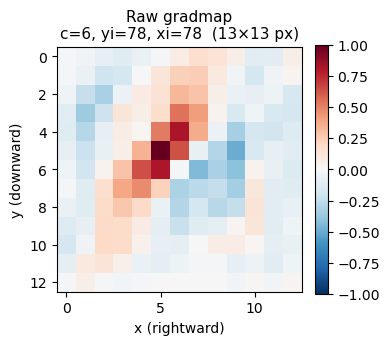

In [17]:
# VIZ 1 — the raw gradmap patch
vabs = np.abs(raw).max()
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(raw, cmap="RdBu_r", vmin=-vabs, vmax=vabs, origin="upper")
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title(f"Raw gradmap\nc={c}, yi={yi}, xi={xi}  ({ph}×{pw} px)", fontsize=11)
ax.set_xlabel("x (rightward)")
ax.set_ylabel("y (downward)")
plt.tight_layout()
plt.show()

In [18]:
# BLOCK 3 — pixel-coordinate grids (centred at 0)
#   xx increases rightward, yy increases downward  (image convention)
ys = np.arange(ph, dtype=np.float32) - ph // 2
xs = np.arange(pw, dtype=np.float32) - pw // 2
yy_np, xx_np = np.meshgrid(ys, xs, indexing="ij")   # both (ph, pw)

print(f"xx_np : shape={xx_np.shape}  range=[{xx_np.min():.1f}, {xx_np.max():.1f}]")
print(f"yy_np : shape={yy_np.shape}  range=[{yy_np.min():.1f}, {yy_np.max():.1f}]")

xx_np : shape=(13, 13)  range=[-6.0, 6.0]
yy_np : shape=(13, 13)  range=[-6.0, 6.0]


In [19]:
# BLOCKS 4+5 — define parameter axes and form the Cartesian product
n_thetas, n_lambdas, n_sigmas = 18, 12, 8

max_lambda = float(min(ph, pw))
max_sigma  = float(min(ph, pw)) / 2.0

thetas  = np.linspace(0.0, math.pi, n_thetas, endpoint=False)
lambdas = np.linspace(2.0, max_lambda, n_lambdas)
sigmas  = np.linspace(max(0.5, max_sigma / n_sigmas), max_sigma, n_sigmas)

print(f"thetas  ({n_thetas}): {np.round(np.degrees(thetas)).astype(int)} deg")
print(f"lambdas ({n_lambdas}): {np.round(lambdas, 1)} px")
print(f"sigmas  ({n_sigmas}):  {np.round(sigmas, 1)} px")

# Cartesian product → flat arrays of length N
th_g, la_g, si_g = np.meshgrid(thetas, lambdas, sigmas, indexing="ij")
print(f"\nmeshgrid shape before ravel: {th_g.shape}  (n_thetas × n_lambdas × n_sigmas)")
th_g = th_g.ravel(); la_g = la_g.ravel(); si_g = si_g.ravel()
N = len(th_g)
print(f"N = {N}  candidate Gabors to evaluate")

thetas  (18): [  0  10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170] deg
lambdas (12): [ 2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13.] px
sigmas  (8):  [0.8 1.6 2.4 3.2 4.1 4.9 5.7 6.5] px

meshgrid shape before ravel: (18, 12, 8)  (n_thetas × n_lambdas × n_sigmas)
N = 1728  candidate Gabors to evaluate


In [20]:
# BLOCK 6 — move to torch and zero-mean / unit-norm the patch
#   (required so that dot products equal Pearson r)
xx_t = torch.tensor(xx_np, device=device)
yy_t = torch.tensor(yy_np, device=device)

p_t = torch.tensor(raw, device=device, dtype=torch.float32).ravel()   # (ph*pw,)
print(f"p_t : shape={p_t.shape}  mean={p_t.mean():.4f}  std={p_t.std():.4f}")

p_t    = p_t - p_t.mean()
p_norm = torch.linalg.norm(p_t)
p_t    = p_t / p_norm
print(f"after normalisation : mean={p_t.mean():.2e}  norm={torch.linalg.norm(p_t):.4f}")

p_t : shape=torch.Size([169])  mean=-0.0016  std=0.2227
after normalisation : mean=7.94e-10  norm=1.0000


In [21]:
# BLOCK 7 — build all N Gabor templates simultaneously (batched)
#
#   x_r = −xx·sin(θ) + yy·cos(θ)   ← across bars (oscillation direction)
#   y_r =  xx·cos(θ) + yy·sin(θ)   ← along bars
#   envelope = exp(−(x_r² + y_r²) / 2σ²)   [γ=1 during grid search]
#   arg      = 2π·x_r / λ
#   G_even   = envelope·cos(arg)
#   G_odd    = envelope·sin(arg)
#   Any G(ψ) = cos(ψ)·G_even − sin(ψ)·G_odd  (free phase handled analytically)

th_t = torch.tensor(th_g, device=device, dtype=torch.float32)[:, None, None]   # (N,1,1)
la_t = torch.tensor(la_g, device=device, dtype=torch.float32)[:, None, None]
si_t = torch.tensor(si_g, device=device, dtype=torch.float32)[:, None, None]
xx_b = xx_t[None]   # (1, ph, pw) — broadcasts to (N, ph, pw)
yy_b = yy_t[None]

with torch.no_grad():
    sin_t = torch.sin(th_t)
    cos_t = torch.cos(th_t)
    x_r   = -xx_b * sin_t + yy_b * cos_t   # (N, ph, pw)
    y_r   =  xx_b * cos_t + yy_b * sin_t   # (N, ph, pw)
    print(f"x_r : {x_r.shape}  (one rotated grid per candidate)")

    env = torch.exp(-(x_r**2 + y_r**2) / (2.0 * si_t**2))   # (N, ph, pw)
    arg = 2.0 * math.pi * x_r / la_t                          # (N, ph, pw)

    G_e = (env * torch.cos(arg)).reshape(N, -1)   # (N, ph*pw)
    G_o = (env * torch.sin(arg)).reshape(N, -1)
    print(f"G_e / G_o : {G_e.shape}  (even/odd Gabor, one row per candidate)")

    # Zero-mean each template (Pearson r convention)
    G_e = G_e - G_e.mean(dim=1, keepdim=True)
    G_o = G_o - G_o.mean(dim=1, keepdim=True)

x_r : torch.Size([1728, 13, 13])  (one rotated grid per candidate)
G_e / G_o : torch.Size([1728, 169])  (even/odd Gabor, one row per candidate)


In [22]:
# BLOCK 8 — analytical best-phase R² for every candidate
#
#   Gram matrix of the {G_e, G_o} basis:
#     Gee = <G_e,G_e>   Goo = <G_o,G_o>   Geo = <G_e,G_o>
#     det = Gee·Goo − Geo²
#
#   Projections of the patch onto the basis:
#     pe = <p, G_e>    po = <p, G_o>
#
#   Maximum R² over ψ (from solving the 2×2 system):
#     R² = [pe·(Goo·pe − Geo·po) + po·(Gee·po − Geo·pe)] / (det·||p||²)

with torch.no_grad():
    Gee = (G_e * G_e).sum(dim=1)   # (N,)
    Goo = (G_o * G_o).sum(dim=1)
    Geo = (G_e * G_o).sum(dim=1)
    det = Gee * Goo - Geo * Geo
    print(f"Gee/Goo/Geo/det : shape={Gee.shape}")
    print(f"  det  min={det.min():.4f}  max={det.max():.4f}")
    print(f"  valid candidates (det > 1e-8): {(det > 1e-8).sum().item()} / {N}")

    pe = G_e @ p_t   # (N,)
    po = G_o @ p_t
    print(f"pe/po : shape={pe.shape}  (projection of patch onto each basis vector)")

    p_norm_sq = float((p_t * p_t).sum().item())   # = 1.0
    print(f"p_norm_sq = {p_norm_sq:.4f}  (should be 1.0)")

    numer  = pe * (Goo * pe - Geo * po) + po * (Gee * po - Geo * pe)
    R2     = (numer / (det * p_norm_sq + 1e-10)).clamp(0.0, 1.0)
    valid  = det > 1e-8
    R2[~valid] = 0.0

    best_i = int(R2.argmax().item())
    print(f"\nbest_i={best_i}  R²={R2[best_i]:.4f}  R={R2[best_i].sqrt():.4f}")
    print(f"  θ={math.degrees(th_g[best_i]):.1f}°  λ={la_g[best_i]:.2f} px  σ={si_g[best_i]:.2f} px")

Gee/Goo/Geo/det : shape=torch.Size([1728])
  det  min=0.0000  max=2229.8523
  valid candidates (det > 1e-8): 1712 / 1728
pe/po : shape=torch.Size([1728])  (projection of patch onto each basis vector)
p_norm_sq = 1.0000  (should be 1.0)

best_i=1202  R²=0.7186  R=0.8477
  θ=120.0°  λ=8.00 px  σ=2.44 px


In [23]:
# BLOCK 9 — recover best phase ψ analytically
#
#   Optimal linear combo: G_best = a·G_even + b·G_odd
#   Solve [ Gee  Geo ] [a]   [pe]
#          [ Geo  Goo ] [b] = [po]
#   → a = (Goo·pe − Geo·po) / det    (weight on the even/cos component)
#   → b = (Gee·po − Geo·pe) / det    (weight on the odd/sin component)
#
#   Since G(ψ) = env·cos(arg+ψ) = cos(ψ)·G_e − sin(ψ)·G_o
#   we have cos(ψ)∝a, sin(ψ)∝−b  →  ψ = atan2(−b, a)

with torch.no_grad():
    Gee_b = float(Gee[best_i]); Goo_b = float(Goo[best_i])
    Geo_b = float(Geo[best_i]); det_b = float(det[best_i])
    pe_b  = float(pe[best_i]);  po_b  = float(po[best_i])

a        = (Goo_b * pe_b - Geo_b * po_b) / det_b
b        = (Gee_b * po_b - Geo_b * pe_b) / det_b
psi_init = float(math.atan2(-b, a))
print(f"a={a:.4f}  b={b:.4f}  →  ψ = atan2(−b, a) = {math.degrees(psi_init):.1f}°")

best_init = [float(th_g[best_i]), float(la_g[best_i]), float(si_g[best_i]), 1.0, psi_init]
print(f"Grid-search result:  θ={math.degrees(best_init[0]):.1f}°  "
      f"λ={best_init[1]:.2f}  σ={best_init[2]:.2f}  γ={best_init[3]}  "
      f"ψ={math.degrees(best_init[4]):.1f}°")

a=0.0803  b=0.2691  →  ψ = atan2(−b, a) = -73.4°
Grid-search result:  θ=120.0°  λ=8.00  σ=2.44  γ=1.0  ψ=-73.4°


In [24]:
# Helper — numpy Gabor (used for visualisation and scipy)
def _gabor_full_np(x, y, theta, lambda_, sigma, gamma, psi):
    xr  = -x * math.sin(theta) + y * math.cos(theta)
    yr  =  x * math.cos(theta) + y * math.sin(theta)
    env = np.exp(-(xr**2 + (gamma * yr)**2) / (2.0 * sigma**2))
    return env * np.cos(2.0 * math.pi * xr / lambda_ + psi)

def _pearson_r(a, b):
    a = a.ravel() - a.mean()
    b = b.ravel() - b.mean()
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom > 1e-8 else 0.0

Grid-search Pearson r = 0.8477


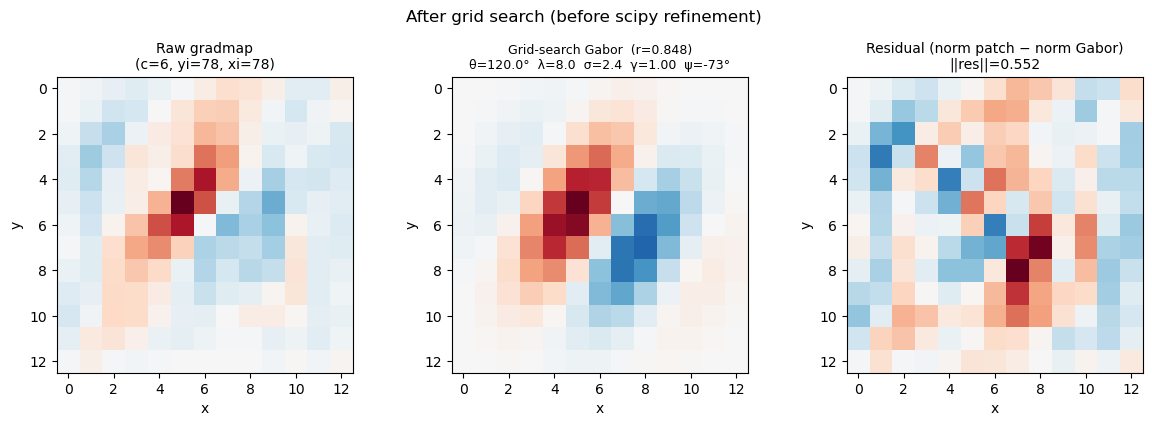

In [25]:
# VIZ 2 — raw patch vs best Gabor from grid search (before scipy)
G_grid = _gabor_full_np(xx_np, yy_np, *best_init)
r_grid = _pearson_r(raw, G_grid)
print(f"Grid-search Pearson r = {r_grid:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

vabs = np.abs(raw).max()
axes[0].imshow(raw,    cmap="RdBu_r", vmin=-vabs, vmax=vabs, origin="upper")
axes[0].set_title(f"Raw gradmap\n(c={c}, yi={yi}, xi={xi})", fontsize=10)

vg = np.abs(G_grid).max()
axes[1].imshow(G_grid, cmap="RdBu_r", vmin=-vg, vmax=vg, origin="upper")
axes[1].set_title(
    f"Grid-search Gabor  (r={r_grid:.3f})\n"
    f"θ={math.degrees(best_init[0]):.1f}°  λ={best_init[1]:.1f}  "
    f"σ={best_init[2]:.1f}  γ={best_init[3]:.2f}  ψ={math.degrees(best_init[4]):.0f}°",
    fontsize=9
)

# Residual = normalised patch − normalised Gabor
p_n = (raw.ravel()    - raw.mean())   / np.linalg.norm(raw.ravel()    - raw.mean())
g_n = (G_grid.ravel() - G_grid.mean()) / np.linalg.norm(G_grid.ravel() - G_grid.mean())
resid_grid = (p_n - g_n).reshape(ph, pw)
vr = np.abs(resid_grid).max()
axes[2].imshow(resid_grid, cmap="RdBu_r", vmin=-vr, vmax=vr, origin="upper")
axes[2].set_title(f"Residual (norm patch − norm Gabor)\n||res||={np.linalg.norm(resid_grid):.3f}",
                  fontsize=10)

for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y")
plt.suptitle("After grid search (before scipy refinement)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [26]:
# BLOCK 10 — scipy TRF least-squares refinement
#
#   Residual vector = p_normalised − G_normalised
#   Zero when perfectly correlated.  TRF handles box bounds.
#   Refines all 5 params: [theta, lambda, sigma, gamma, psi]

patch_flat = raw.ravel().astype(np.float64)
p_c  = patch_flat - patch_flat.mean()
p_c /= np.linalg.norm(p_c)
print(f"p_c : shape={p_c.shape}  norm={np.linalg.norm(p_c):.4f}")

def residuals(params):
    theta, lambda_, sigma, gamma, psi = params
    G   = _gabor_full_np(xx_np, yy_np, theta, lambda_, sigma, gamma, psi)
    G_c = G.ravel() - G.mean()
    Gn  = np.linalg.norm(G_c)
    if Gn < 1e-8:
        return np.ones_like(p_c)
    return p_c - G_c / Gn   # (ph*pw,) — zero when perfectly correlated

x0     = np.clip(best_init,
                 [0.0, 1.5, 0.3, 0.1, -math.pi],
                 [math.pi, max_lambda, max_sigma, 4.0, math.pi])
bounds = ([0.0, 1.5, 0.3, 0.1, -math.pi],
          [math.pi, max_lambda, max_sigma, 4.0,  math.pi])

print(f"x0 : θ={math.degrees(x0[0]):.1f}°  λ={x0[1]:.2f}  σ={x0[2]:.2f}  γ={x0[3]:.2f}  ψ={math.degrees(x0[4]):.1f}°")
print(f"residual norm at x0 = {np.linalg.norm(residuals(x0)):.4f}")

res   = least_squares(residuals, x0, bounds=bounds, method="trf", max_nfev=2000)
p_opt = res.x
print(f"\nConverged in {res.nfev} function evals  cost={res.cost:.6f}")
print(f"  θ={math.degrees(p_opt[0]):.2f}°  λ={p_opt[1]:.3f}  σ={p_opt[2]:.3f}  γ={p_opt[3]:.3f}  ψ={math.degrees(p_opt[4]):.2f}°")

p_c : shape=(169,)  norm=1.0000
x0 : θ=120.0°  λ=8.00  σ=2.44  γ=1.00  ψ=-73.4°
residual norm at x0 = 0.5519

Converged in 1 function evals  cost=0.152291
  θ=120.00°  λ=8.000  σ=2.438  γ=1.000  ψ=-73.39°


In [27]:
# BLOCK 11 — compute final Pearson r
theta_f, lambda_f, sigma_f, gamma_f, psi_f = p_opt
theta_f = float(theta_f % math.pi)

G_final = _gabor_full_np(xx_np, yy_np, theta_f, lambda_f, sigma_f, gamma_f, psi_f)
final_r = _pearson_r(raw, G_final)

print(f"Grid-search r = {r_grid:.4f}")
print(f"Refined     r = {final_r:.4f}  (Δr = {final_r - r_grid:+.4f})")
print(f"R² explained  = {final_r**2:.4f}")

Grid-search r = 0.8477
Refined     r = 0.8477  (Δr = +0.0000)
R² explained  = 0.7186


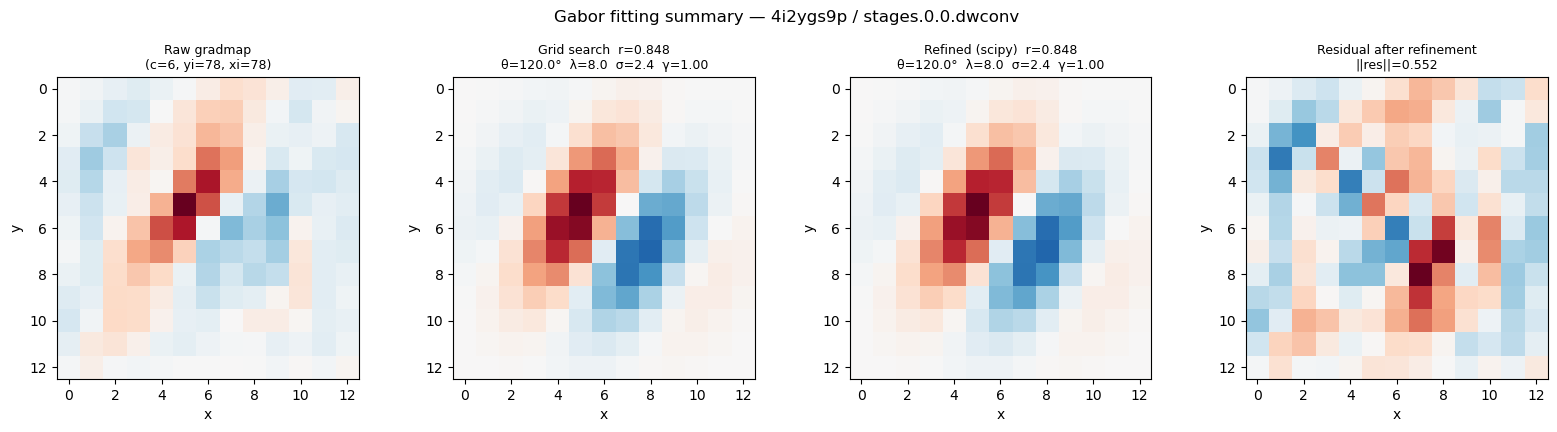

In [28]:
# VIZ 3 — full comparison: raw | grid-search Gabor | refined Gabor | refined residual
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

def _show(ax, img, title, cmap="RdBu_r", vabs=None):
    v = vabs if vabs else np.abs(img).max() + 1e-9
    ax.imshow(img, cmap=cmap, vmin=-v, vmax=v, origin="upper")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("x"); ax.set_ylabel("y")

_show(axes[0], raw,
      f"Raw gradmap\n(c={c}, yi={yi}, xi={xi})")

_show(axes[1], G_grid,
      f"Grid search  r={r_grid:.3f}\n"
      f"θ={math.degrees(best_init[0]):.1f}°  λ={best_init[1]:.1f}  "
      f"σ={best_init[2]:.1f}  γ={best_init[3]:.2f}")

_show(axes[2], G_final,
      f"Refined (scipy)  r={final_r:.3f}\n"
      f"θ={math.degrees(theta_f):.1f}°  λ={lambda_f:.1f}  "
      f"σ={sigma_f:.1f}  γ={gamma_f:.2f}")

p_n  = (raw.ravel()     - raw.mean())    / np.linalg.norm(raw.ravel()     - raw.mean())
gf_n = (G_final.ravel() - G_final.mean()) / np.linalg.norm(G_final.ravel() - G_final.mean())
resid_final = (p_n - gf_n).reshape(ph, pw)
_show(axes[3], resid_final,
      f"Residual after refinement\n||res||={np.linalg.norm(resid_final):.3f}")

plt.suptitle(
    f"Gabor fitting summary — {model_name} / {layer_name}",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()